# Data Selection and Study Sets
---
### Dataset: Mamirauá Sustainable Development Institute (IDSM)

NOTE: Some functions of this notebook will not work because they rely on .wav audio data or are unavailable due to being designed for data organization using pandas.

In [ ]:
import pandas as pd
import sys
from pathlib import Path

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Project root added to sys.path: {PROJECT_ROOT}")
else:
    print("ERROR: Could not find the project root.")

IDSM_REGEX = (
    r"(?P<recorder>[A-Z0-9]+)_"
    r"(?P<year>\d{4})(?P<month>\d{2})(?P<day>\d{2})_"
    r"(?P<hour>\d{2})(?P<minute>\d{2})(?P<second>\d{2})"
    r"(?:_?(?P<rain_mm_str>\d+-\d+))?"       
    r"(?:_?(?P<category>[a-zA-Z0-9-]+))?"
)
ALL_CLASSES = ['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent', 'Unlabeled']
RAIN_CLASSES = ['Light', 'Moderate', 'Heavy', 'Violent']
WMO_CLASSES = ['no-rain', 'light', 'moderate', 'heavy', 'violent']

## Ingestion

In [35]:
raw_data_output_dir = PROJECT_ROOT / "data" / "raw" / "IDSM"

metadata_file_path = raw_data_output_dir / "idsm_metadata.csv"
merged_file_path = raw_data_output_dir / "idsm_merged.csv"

df_raw = (
    scan_files(RAW_DIR)
    .pipe(extract_filename_metadata, regex_pattern=IDSM_REGEX)
    .query("recorder == 'SMM00894'")
    .pipe(save_checkpoint, file_path=metadata_file_path, index=False)
    .pipe(merge_ground_truth, audit_path=AUDIT_PATH, gt_mapping=AUDIT_MAPPING, no_overwrite=['period'])
    .pipe(save_checkpoint, file_path=merged_file_path, index=False)
)

In [36]:
df_metadata = pd.read_csv(metadata_file_path)
df_merged = pd.read_csv(merged_file_path)

count_metadata = df_metadata['category'].value_counts()
print('df_metadata:')
print(count_metadata, '\n')

count_merged = df_merged['category'].value_counts()
print('df_merged:')
print(count_merged, '\n')

df_metadata:
category
no-rain      50187
unlabeled     4217
moderate       591
light          517
heavy          262
violent         64
Name: count, dtype: int64 

df_merged:
category
no-rain      50187
unlabeled     4217
moderate       591
light          517
heavy          262
violent         64
Name: count, dtype: int64 



## Datset Distributions

15:44:55 - [VizEngine] - INFO - Figure saved: IDSM_donut_all.pdf
15:44:55 - [VizEngine] - INFO - Figure saved: IDSM_donut_all.png
15:44:55 - [VizEngine] - INFO - Figure saved: IDSM_stacked_rain.pdf
15:44:55 - [VizEngine] - INFO - Figure saved: IDSM_stacked_rain.png


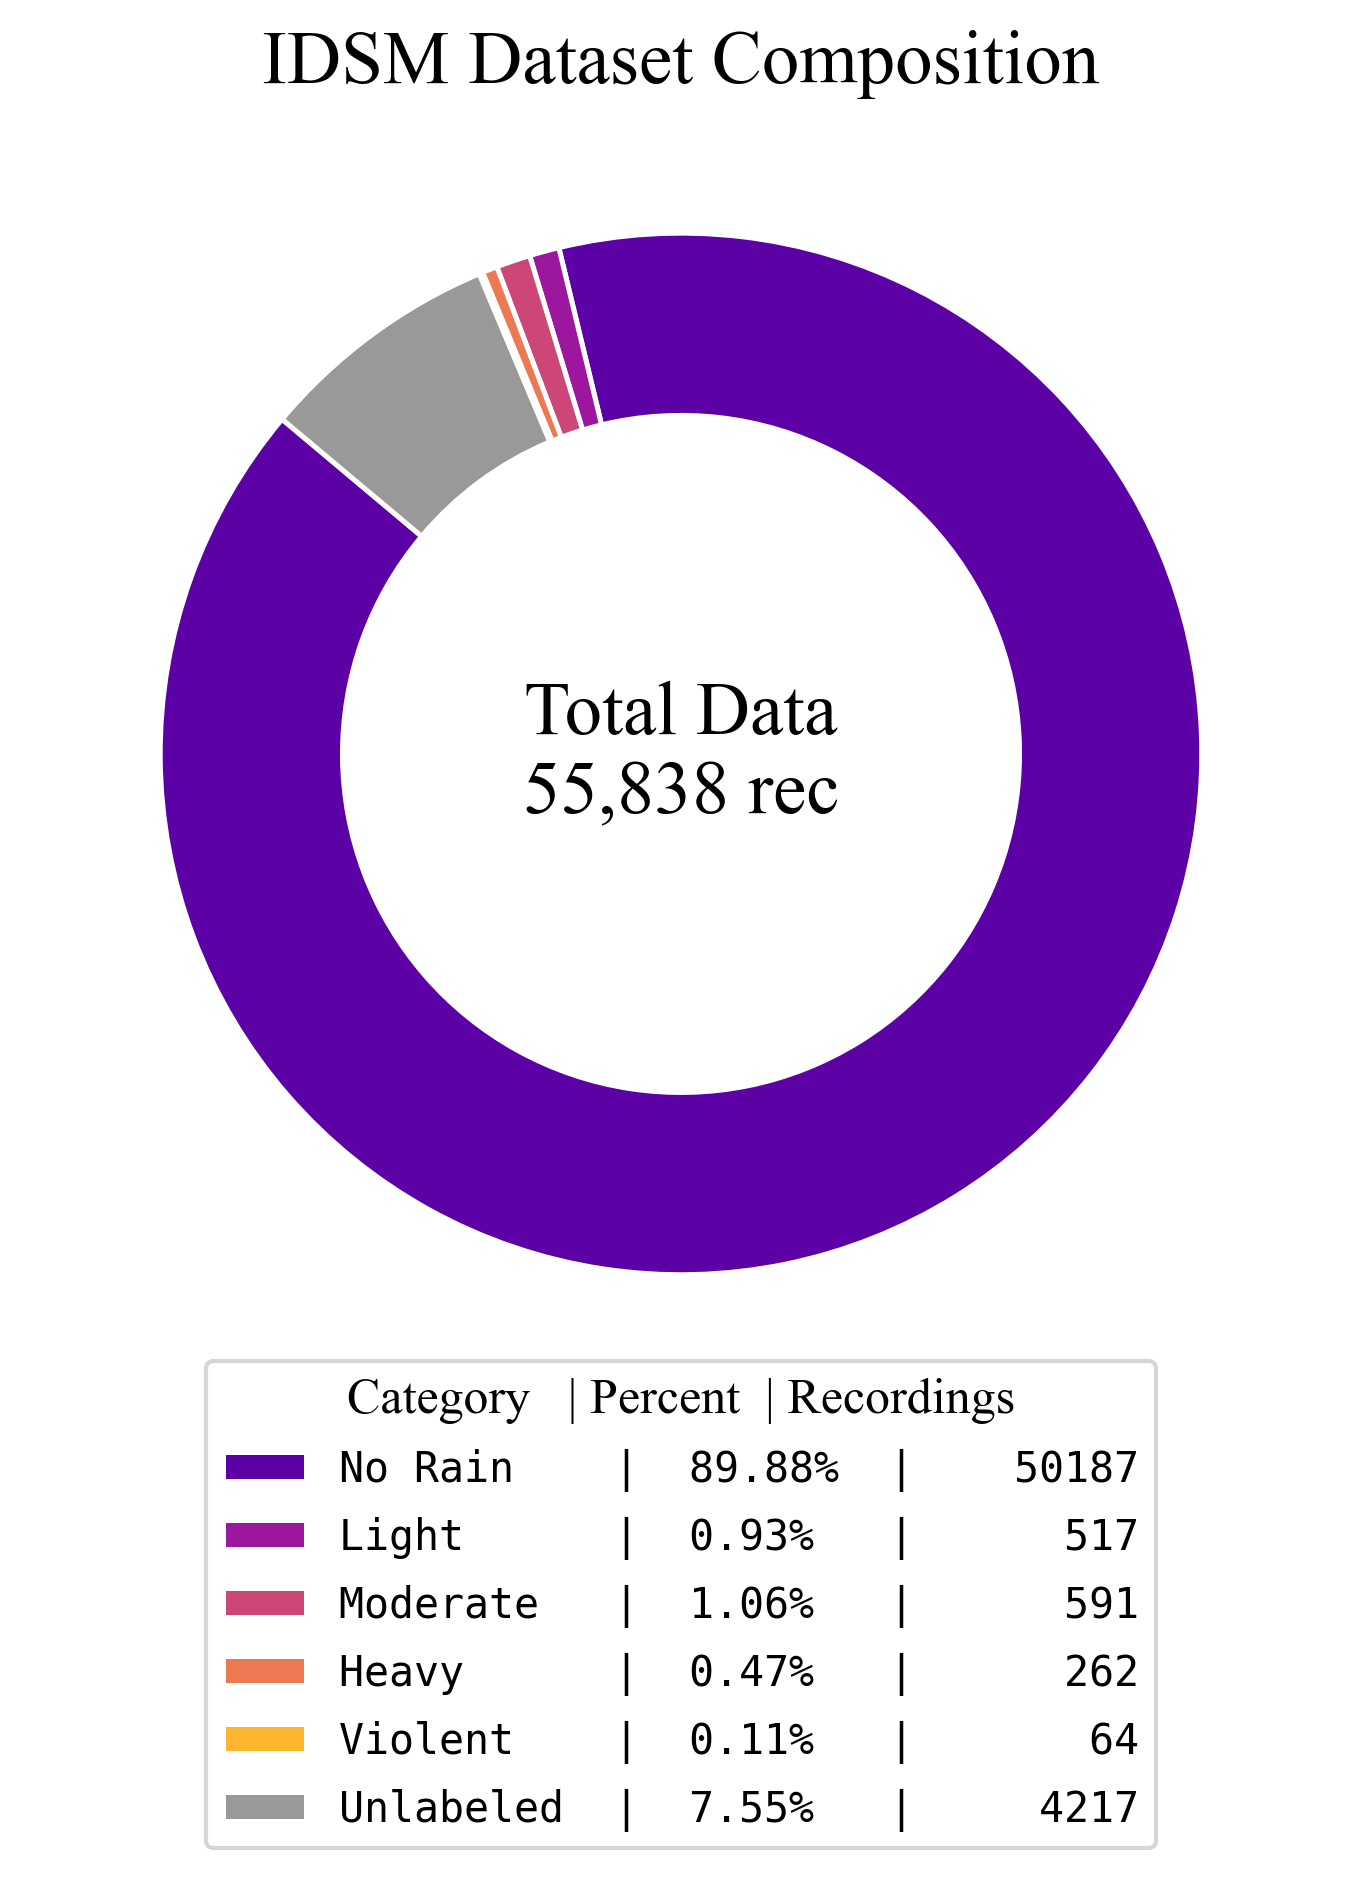

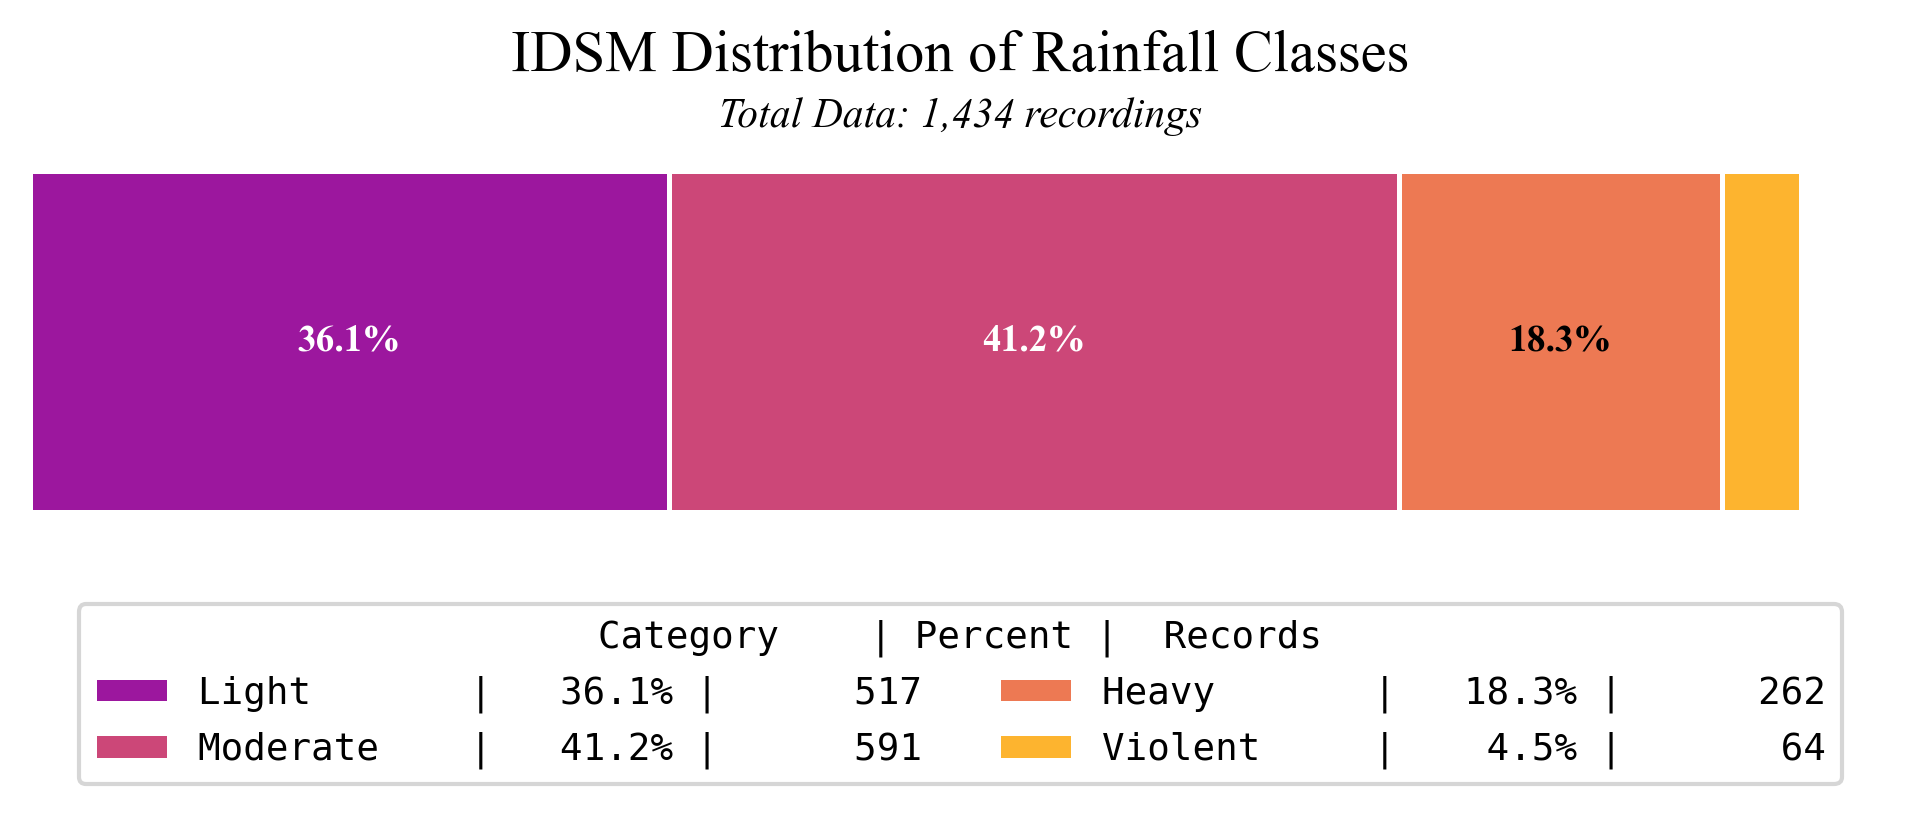

In [40]:
fig_donut_all = plot_styled_donut(df_raw_viz, engine, ALL_CLASSES, "IDSM Dataset Composition")
engine.save_figure(fig_donut_all, "IDSM_donut_all")

fig_bar_rain = plot_styled_stacked_bar(df_raw_viz, engine, RAIN_CLASSES, "IDSM Distribution of Rainfall Classes")
engine.save_figure(fig_bar_rain, "IDSM_stacked_rain")

## Monthly Distribuiton

15:44:55 - [VizEngine] - INFO - Figure saved: IDSM_monthly_distribution_bars.pdf
15:44:56 - [VizEngine] - INFO - Figure saved: IDSM_monthly_distribution_bars.png


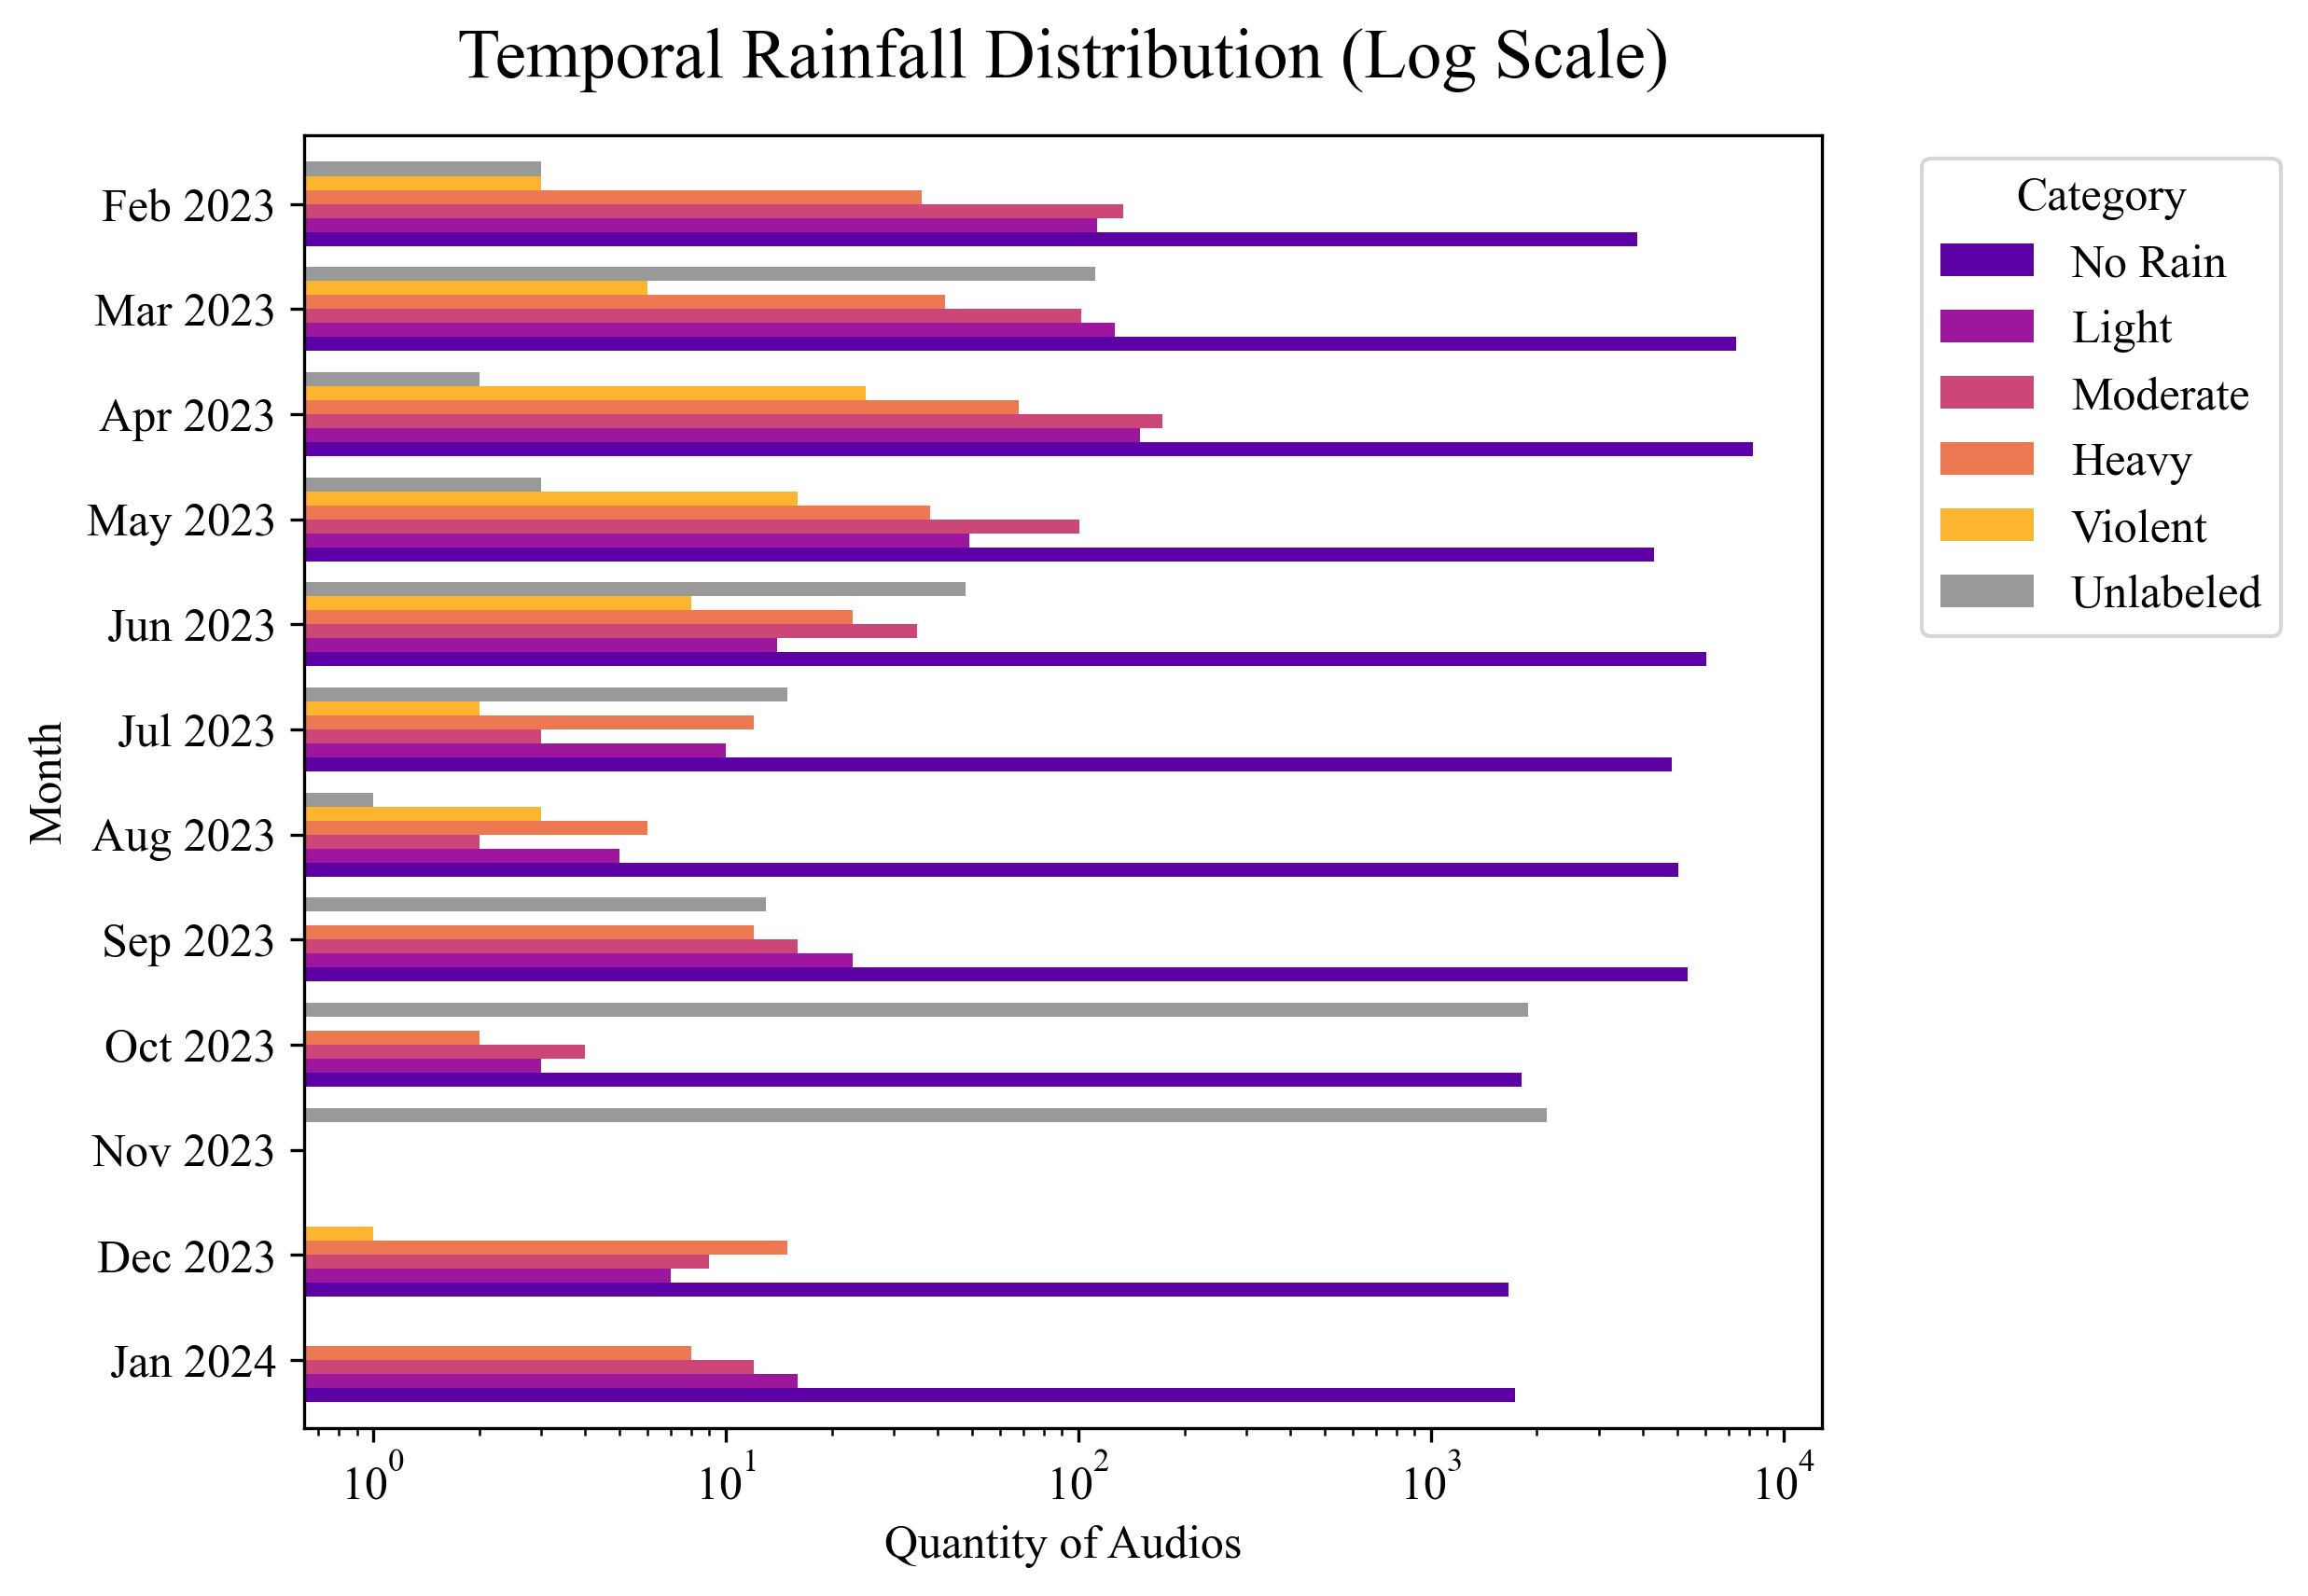

In [41]:
fig_temporal = plot_temporal_log_distribution(df_raw_viz, engine)
engine.save_figure(fig_temporal, "IDSM_monthly_distribution_bars")

## Monthly Percentages

15:44:56 - [VizEngine] - INFO - Figure saved: IDSM_matrix_percentages_all.pdf
15:44:56 - [VizEngine] - INFO - Figure saved: IDSM_matrix_percentages_all.png
15:44:56 - [VizEngine] - INFO - Figure saved: IDSM_matrix_percentages_rain.pdf
15:44:56 - [VizEngine] - INFO - Figure saved: IDSM_matrix_percentages_rain.png


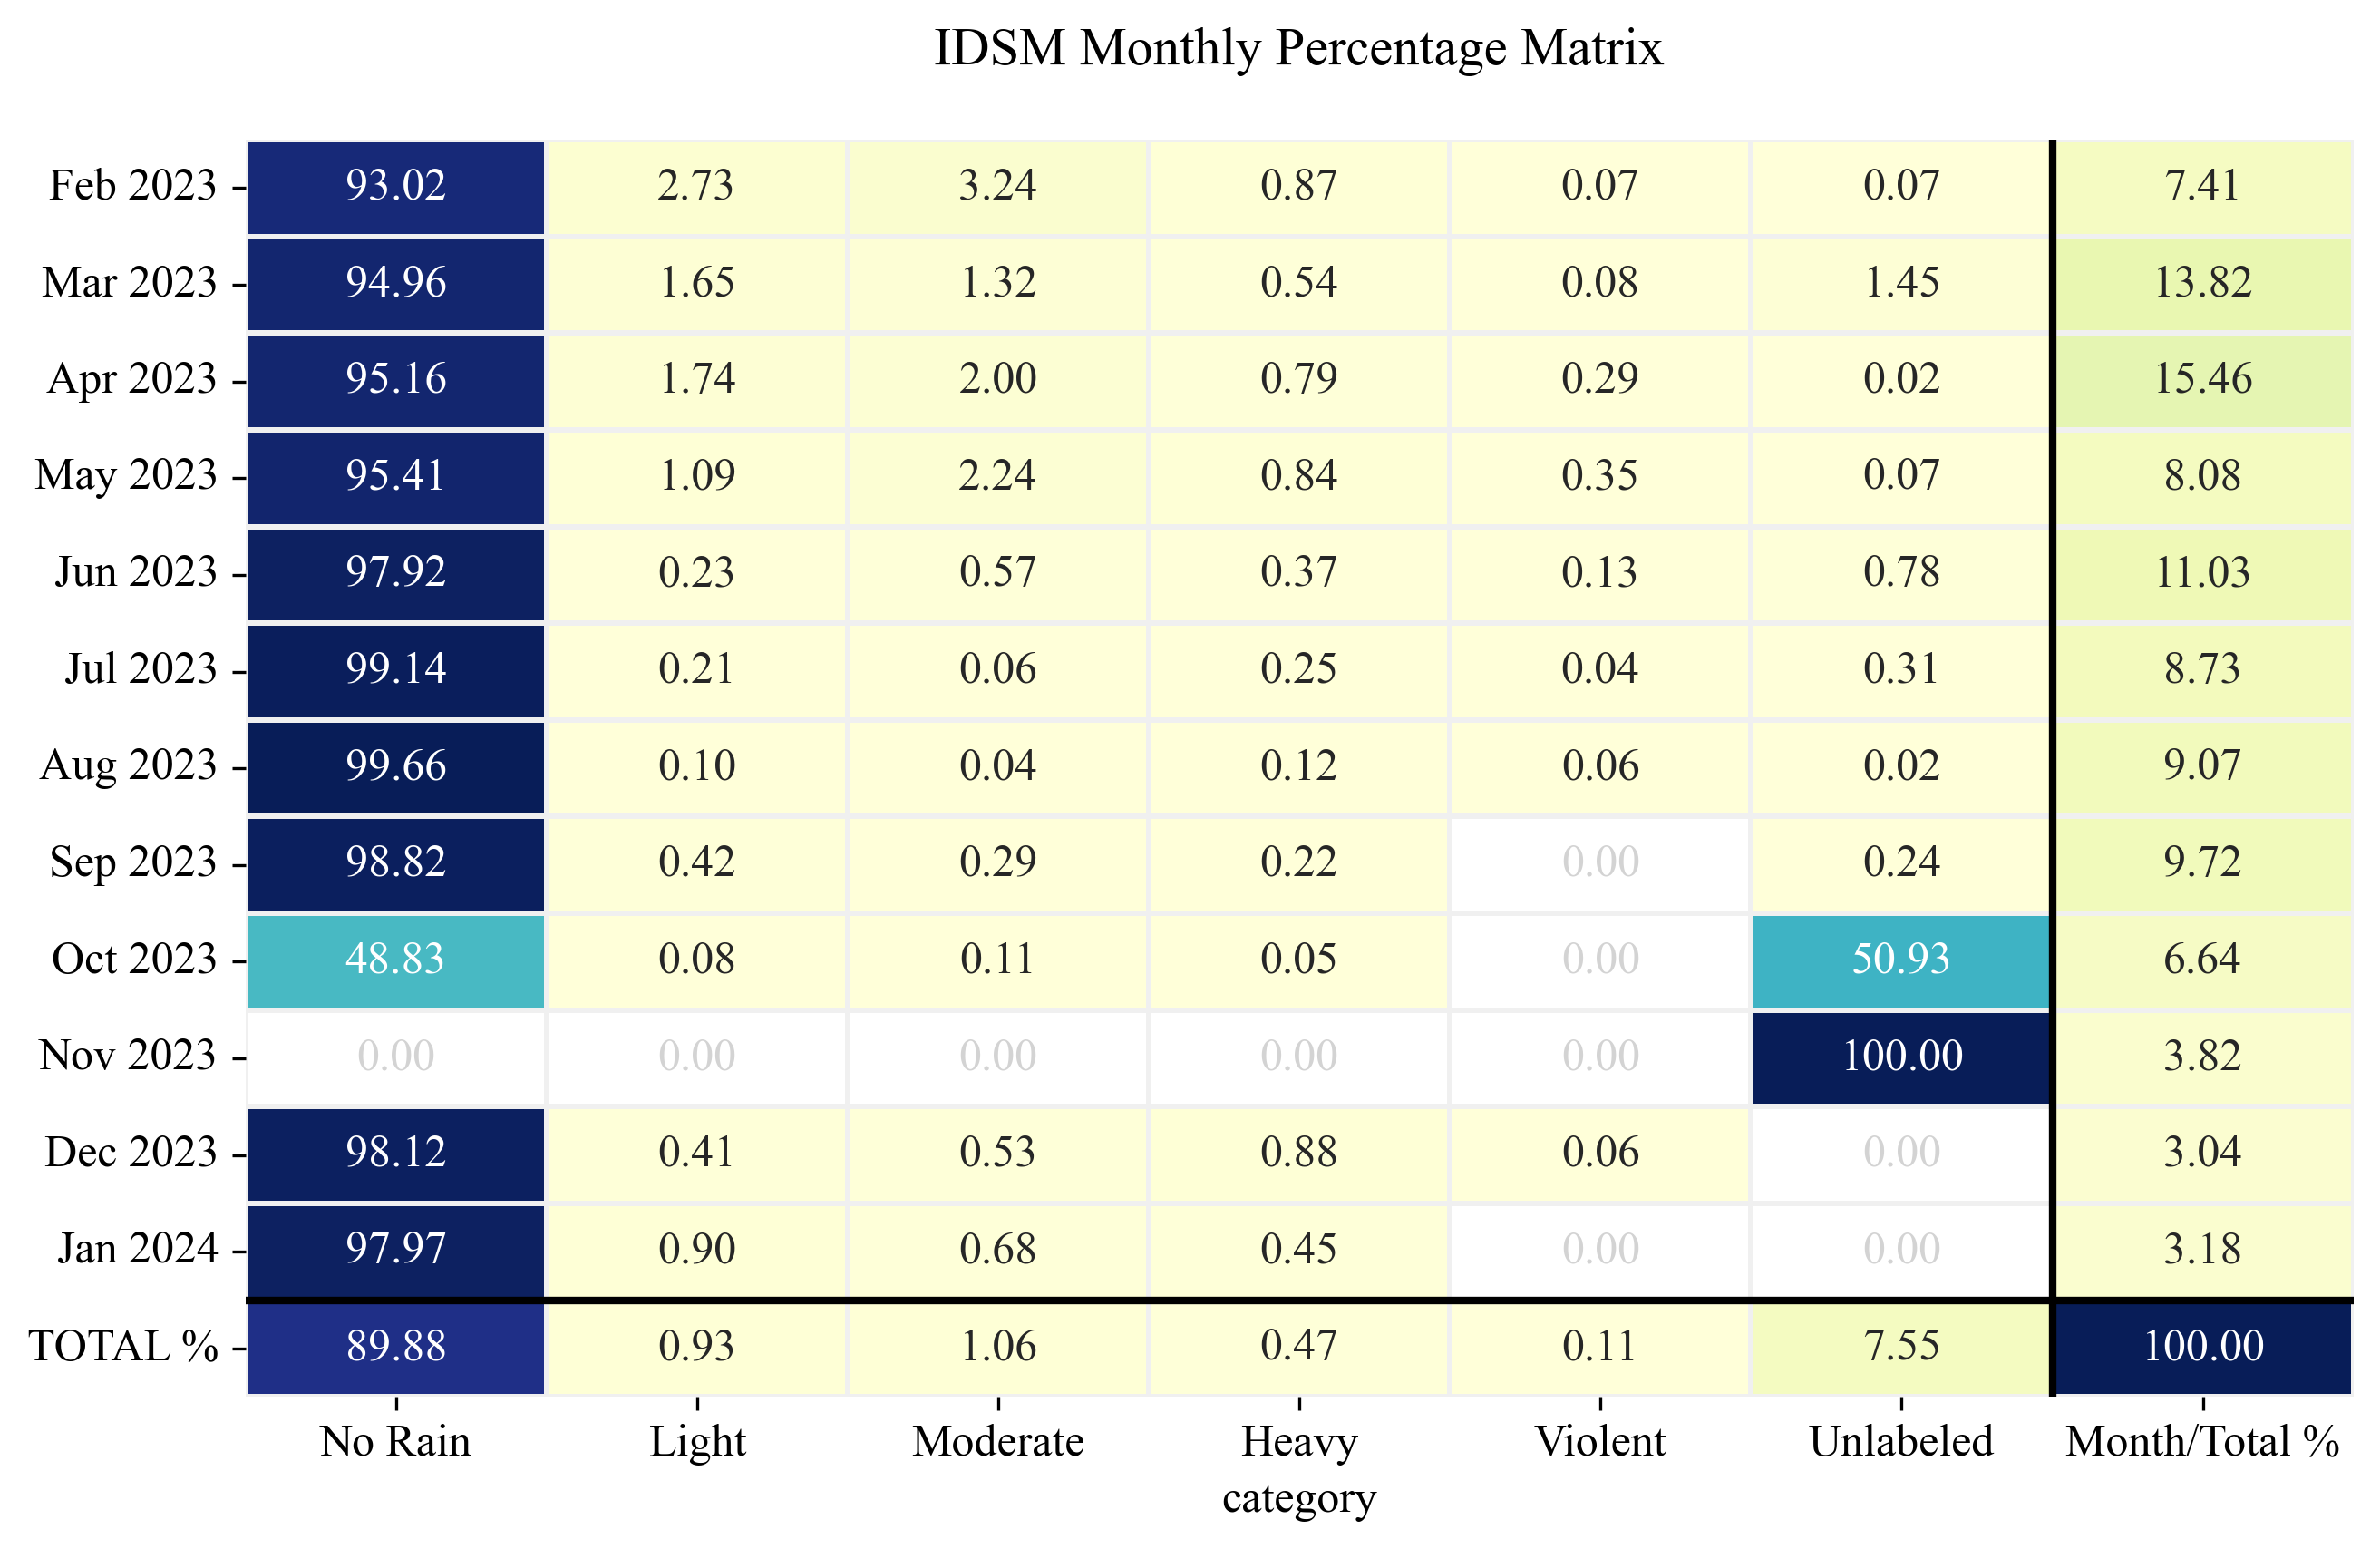

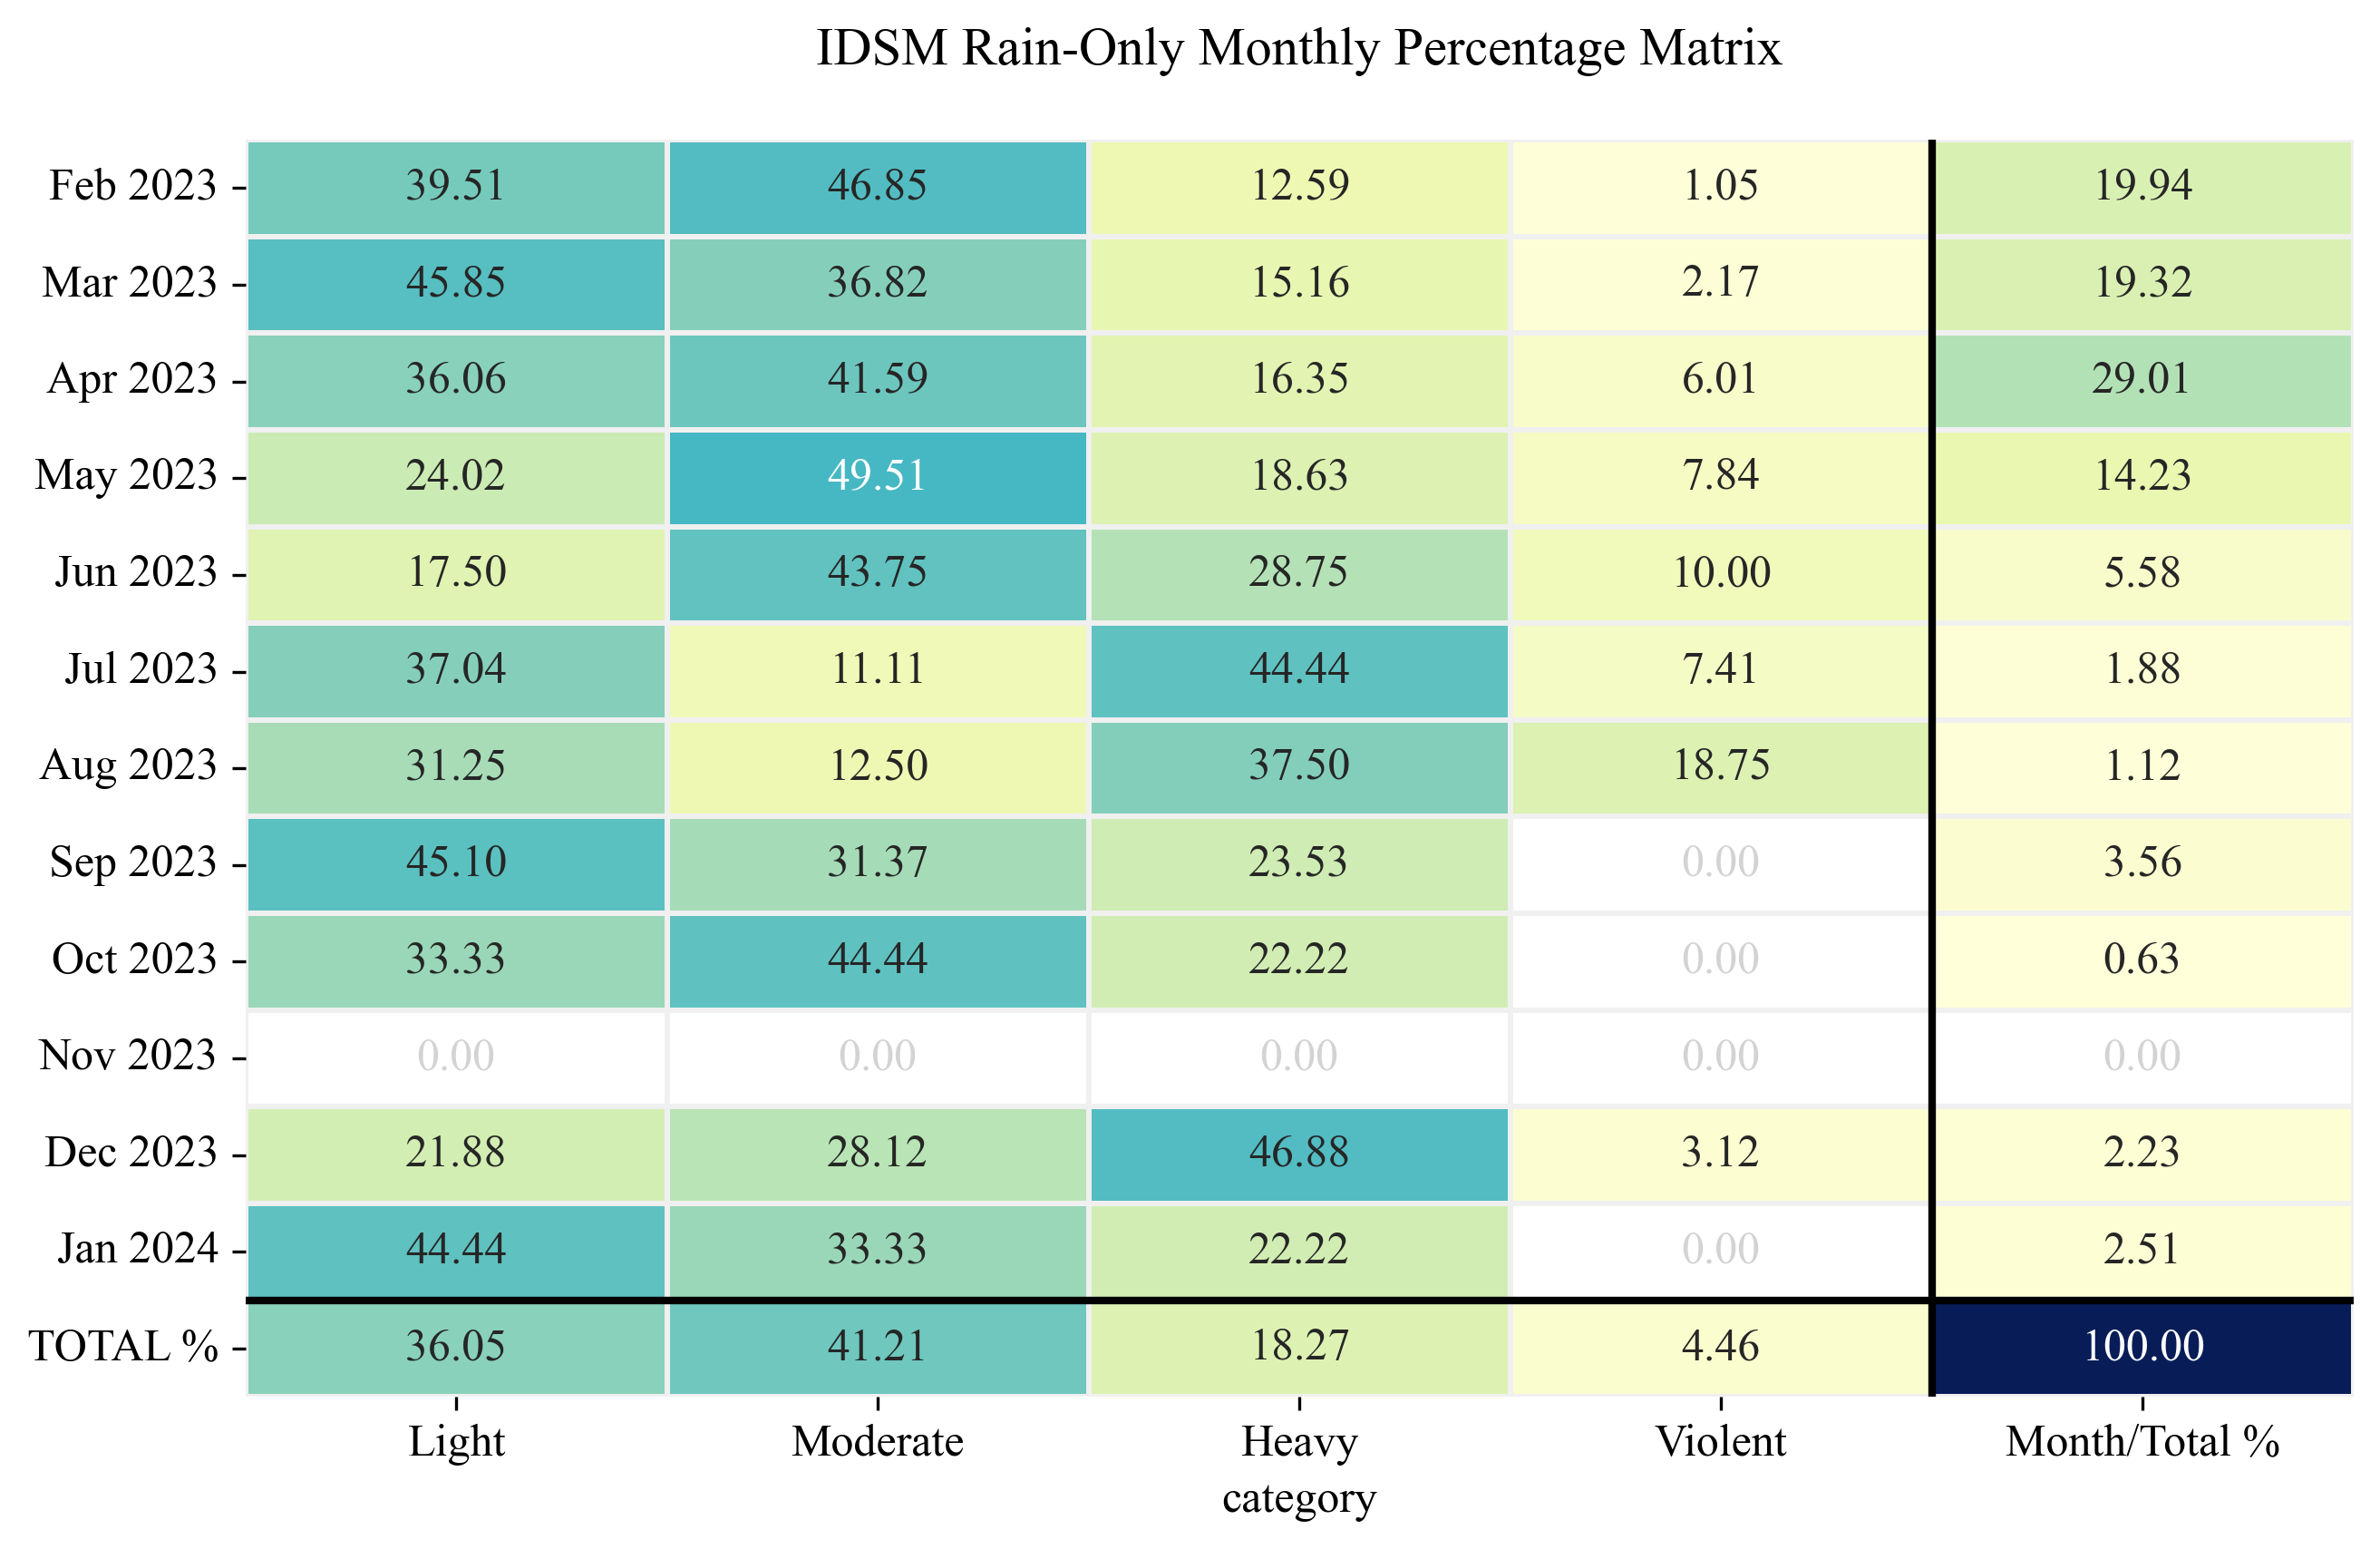

In [42]:
# All dataset
months_order = df_raw_viz['month_label'].cat.categories

matrix_p = pd.crosstab(df_raw_viz['month_label'], df_raw_viz['category'], normalize='index', dropna=False) * 100
month_weights = (df_raw_viz['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p['Month/Total %'] = month_weights

total_class_p = (df_raw_viz['category'].value_counts(normalize=True).reindex(ALL_CLASSES) * 100).to_frame().T
total_class_p.index = ['TOTAL %']
total_class_p['Month/Total %'] = 100.0
matrix_p_final = pd.concat([matrix_p, total_class_p])

fig_matrix_p = plot_custom_matrix(matrix_p_final, "IDSM Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p, "IDSM_matrix_percentages_all")


# Only Rain data
df_rain = df_raw_viz[df_raw_viz['category'].isin(RAIN_CLASSES)].copy()
df_rain['category'] = df_rain['category'].cat.remove_unused_categories()

matrix_p_rain = pd.crosstab(df_rain['month_label'], df_rain['category'], normalize='index', dropna=False) * 100
month_weights_rain = (df_rain['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p_rain['Month/Total %'] = month_weights_rain

total_rain_p = (df_rain['category'].value_counts(normalize=True).reindex(RAIN_CLASSES) * 100).to_frame().T
total_rain_p.index = ['TOTAL %']
total_rain_p['Month/Total %'] = 100.0
matrix_p_rain_final = pd.concat([matrix_p_rain, total_rain_p])

fig_matrix_p_rain = plot_custom_matrix(matrix_p_rain_final, "IDSM Rain-Only Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p_rain, "IDSM_matrix_percentages_rain")

## Selection

In [43]:
curated_file_path = PROJECT_ROOT / "data" / "raw" / "IDSM" / "IDSM_curated.csv"
one_to_one_file_path = PROJECT_ROOT / "data" / "raw" / "IDSM" / "IDSM_1_to_1.csv"

df_cleaned = (
    df_raw
    .pipe(discard_files, discard_rules=[
        "category == 'unlabeled'",
        "category.isnull() or mm_5min.isnull() or mm_hr.isnull()",
        "wet == True and mm_5min == 0", 
        "wet == False and mm_5min > 0",
        "(file_name >= 'SMM00894_20230602_191500_0-2_no-rain_night.wav') and (file_name <= 'SMM08558_20240215_133000_0-0_no-rain_afternoon.wav')"
    ])
    .pipe(save_checkpoint, file_path=curated_file_path, index=False)
    .pipe(undersample_1_to_1, target_col='category', anchor_classes=WMO_CLASSES[1:5], sample_classes=[WMO_CLASSES[0]])
    .pipe(save_checkpoint, file_path=one_to_one_file_path, index=False)
)

15:44:57 - [DataCurator] - INFO - Applying 5 discard rule(s)...
15:44:57 - [DataCurator] - INFO - Curation complete. Remaining records: 23635 (Original: 55838).
15:44:57 - [DataBalancer] - INFO - Initiating 1:1 undersamplig on column 'category'.
15:44:57 - [DataBalancer] - INFO - Anchor group size: 1186 | Pool group size: 22449
15:44:57 - [DataBalancer] - INFO - Balanced Dataset generated: 2372 total records.


In [44]:
df_curated = pd.read_csv(curated_file_path)
df_one_to_one = pd.read_csv(one_to_one_file_path)

count_raw = df_raw['category'].value_counts()
print('df_raw:')
print(count_raw, '\n')

count_curated = df_curated['category'].value_counts()
print('df_curated:')
print(count_curated, '\n')

count_one_to_one = df_one_to_one['category'].value_counts()
print('df_1_to_1:')
print(count_one_to_one, '\n')

df_raw:
category
no-rain      50187
unlabeled     4217
moderate       591
light          517
heavy          262
violent         64
Name: count, dtype: int64 

df_curated:
category
no-rain     22449
moderate      509
light         440
heavy         187
violent        50
Name: count, dtype: int64 

df_1_to_1:
category
no-rain     1186
moderate     509
light        440
heavy        187
violent       50
Name: count, dtype: int64 



## Stratified Split

In [45]:
split_file_path = PROJECT_ROOT / "data" / "splits" / "IDSM"

train_file_path = split_file_path / "IDSM_train.csv"
val_file_path = split_file_path / "IDSM_val.csv"
test_file_path = split_file_path / "IDSM_test.csv"


df_train, df_val, df_test = split_dataset(
    df_cleaned, 
    test_size=0.1, 
    val_size=0.1, 
    stratify_cols=['category']
)


df_train.to_csv(train_file_path, index=False)
df_val.to_csv(val_file_path, index=False)
df_test.to_csv(test_file_path, index=False)

In [46]:
count_train = df_train['category'].value_counts()
print('TRAIN:')
print(count_train)
print("Total Samples    ", len(df_train['category']), '\n')

count_val = df_val['category'].value_counts()
print('VALIDATION:')
print(count_val)
print("Total Samples    ", len(df_val['category']), '\n')

count_test = df_test['category'].value_counts()
print('TEST')
print(count_test)
print("Total Samples    ", len(df_test['category']), '\n')

total = len(df_test['category']) + len(df_val['category']) + len(df_train['category'])

print("PERCENTAGES:")
print("Train         ", round((len(df_train['category'])/total), 2))
print("Validation    ", round((len(df_val['category'])/total), 2))
print("Test          ", round((len(df_test['category'])/total), 2))



TRAIN:
category
no-rain     948
moderate    407
light       352
heavy       149
violent      40
Name: count, dtype: int64
Total Samples     1896 

VALIDATION:
category
no-rain     119
moderate     51
light        44
heavy        19
violent       5
Name: count, dtype: int64
Total Samples     238 

TEST
category
no-rain     119
moderate     51
light        44
heavy        19
violent       5
Name: count, dtype: int64
Total Samples     238 

PERCENTAGES:
Train          0.8
Validation     0.1
Test           0.1
